# **PROYECTO FINAL- SINIESTROS VIALES 2015-2020 - SiniBogotá**

**Curso Aprendizaje de Máquinas**

**Integrantes:**

*   Santiago Orjuela - santiago_orjuela@javeriana.edu.co
*   Laura Beltran Arias - beltranla@javeriana.edu.co
*   Nicolas Avila - avila.bnicolas@javeriana.edu.co





## **Modelo base de Regresión Logística**

## **Planeación**

### Contexto:

La seguridad vial constituye uno de los principales retos de gestión pública en Bogotá, donde la alta densidad poblacional, el aumento en el uso de vehiculos y la diversidad de actores viales generan condiciones complejas de movilidad.

Para darnos una idea, entre 2021 y 2024, las muertes por siniestros viales en Bogotá presentaron un aumento sostenido, solo para 2025 se ha logrado una reducción cercana al 2% frente al 2024, esto segun estudios del Observatorio Nacional de Seguridad Vial. (11 Feb 2026, Bogota.Gov.co, Gina R Sánchez)

En adición, durante los últimos años, la ciudad ha experimentado eventos atípicos y restricciones sin precedentes, como las medidas de confinamiento por la pandemia de COVID-19, jornadas de “día sin carro”, protestas sociales y variaciones significativas en la movilidad urbana.


Estos eventos alteran drásticamente:

- El volumen de tráfico

- Los patrones de desplazamiento

- El comportamiento de los actores viales

- La capacidad de control por parte de las autoridades

Sin embargo, no es claro si estas variaciones generan reducciones sostenidas en la frecuencia de siniestros, cambios en la severidad de los mismos o efectos temporales o estructurales frente al comportamiento de los usuarios.

Por si fuera poco, aunque el Distrito impone miles de comparendos cada año como mecanismo de control y disuasión, no existe evidencia clara de su impacto real en la reducción de la siniestralidad.


### Fuentes de Datos:

**Set Principal**

Los datos de siniestros viales en Bogotá que cubren el periodo comprendido entre el 1 de enero de 2015 y el 31 de diciembre de 2020.


***Fuente:***
Secretaría Distrital de Movilidad

Este data set esta distribuido en cinco tablas:

1.   Siniestros: Detalles del Siniestro
2.   Actores Viales: Detalles de los actores viales afectados
3.   Vehiculos: Detalles de los vehiculos
4.   Hipotesis: Código causa
5.   Diccionario: Descripciones de los sets anteriores


**Datos Complementarios**

Tenemos los siguientes data sets complementarios:

1. **Calendario 2015-2020** Contiene el día de la semana, si es festivo, si hay día sin carro, si hay covid, si hay protesta o algun evento relevante.
Fuente: Creado manualmente.


2. **Clima 2015-2020** La fuente IDEAM aporta observaciones diarias de precipitación por estación en la ciudad de Bogotá, extrayendo datos en un período de tiempo del año 2015 al 2020.



**Nota:** Todos los datasets los hemos subido a Git hub.

## **Estrategia de Integración de Datos**

Para enriquecer el análisis utilizaremos una estrategia de unión por cada una de los sets de datos.  

**Estrategia de Integración** (Relaciones 1:N)

### Set Principal (Siniestros)

La base de datos de siniestros viales constituye el eje central del estudio, ya que contiene información detallada sobre la ocurrencia, severidad, localización y características de los accidentes en Bogotá.


- **Set Calendario:**
Relación: 1 a 1.
Cruce directo por FECHA para etiquetar el contexto de cada accidente.

- **Set de Vehículos:**
Relación: 1 a Varios. Un CODIGO_ACCIDENTE puede tener varios vehículos.

   Estrategia: Se debe decidir si se aplana la base (contar cuántos vehículos hubo por accidente) o si se mantiene el detalle para analizar fallas mecánicas por tipo de vehículo.

- **Set de Actor Vial:**
Relación: 1 a Varios. Un accidente involucra a varias personas con diferentes roles.

  Estrategia: Cruce por CODIGO_ACCIDENTE. Es vital para identificar, por ejemplo, cuántos heridos hubo por cada tipo de vehículo involucrado.

- **Set de Hipótesis:**
Relación: 1 a Varios. Un accidente puede tener múltiples causas (ej. Lluvia + Embriaguez).

### Set Complementario 1 (Calendario 2015-2020)

El calendario de eventos especiales y restricciones de movilidad permite contextualizar los siniestros dentro de dinámicas externas que alteran el comportamiento del tráfico y los patrones de desplazamiento urbano bajo un enfoque de caracter temporal.

- **Calendario 2015 a 2020:**
Relación: Varios a Varios. Permite identificar eventos importantes mediante el cruce de fechas para las cuales ocurrieron los siniestros (ej. Dia festivo, día sin carro, protestas, etc.).


### Set Complementario 2 (Clima 2015-2020)

La fuente IDEAM aporta observaciones diarias de precipitación por estación; para integrarlas con la unidad de análisis accidente, se construyen variables agregadas diarias a nivel ciudad.



In [61]:
# DICCIONARIO SINIESTRALIDAD

import pandas as pd
import numpy as np

siniestros_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'HORA', 'GRAVEDAD', 'CLASE_SINIESTRO',
        'CHOQUE', 'OBJETO_FIJO', 'DIRECCION', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String', 'String', 'String',
        'String', 'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro',
        'Fecha del evento (DD/MM/AAAA)',
        'Hora del reporte del accidente',
        'Código Nivel de afectación (Muertos, Heridos, Daños)',
        'Código Tipo de accidente (Choque, Atropello, etc.)',
        'Código (Carro, Tren, Objetivo Fijo, Semoviente)',
        'Código Elemento chocado (Poste, árbol, semáforo, etc.)',
        'Ubicación de la colisión',
        'Identificador de la localidad en Bogotá',
        'Código Tipo de infraestructura (Intersección, tramo, puente, ect.)'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '01:05:00', '2', '2',
        '1', '2', 'KR 64A-CL 2C 02', '16', '2'
    ]
}

df_siniestros_dictionary = pd.DataFrame(siniestros_data)


In [62]:

# Diccionario Actor Vial
actor_vial_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'CODIGO_ACCIDENTADO', 'FECHA',
        'CONDICION', 'ESTADO', 'EDAD', 'SEXO', 'VEHICULO'
    ],
    'Tipo de Dato': [
        'String', 'String', 'Date',
        'String', 'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro (Llave de unión)',
        'ID único de la persona involucrada',
        'Fecha del evento (DD/MM/AAAA)',
        'Rol del actor (Conductor, Peatón, Pasajero, etc.)',
        'Gravedad física (Ileso, Herido, Muerto)',
        'Años de la persona involucrada',
        'Género del actor vial',
        'ID del vehículo asociado al actor'
    ],
    'Ejemplo': [
        '4401447', '2452576', '01/01/2015',
        'CONDUCTOR', 'ILESO', '44', 'FEMENINO', '4401447-1'
    ]
}

# Generar el DataFrame
df_actor_vial_dictionary = pd.DataFrame(actor_vial_data)


In [63]:
# Diccionario para la base de Vehículos
vehiculos_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'VEHICULO',
        'CLASE_VEHICULO', 'SERVICIO', 'MODALIDAD', 'ENFUGA'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String',
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro (Llave de unión)',
        'Fecha del evento (DD/MM/AAAA)',
        'ID interno del vehículo en el accidente',
        'Código Tipo de vehículo (Automóvil, Bus, Camión, etc.)',
        'Código Tipo de servicio (Particular, Público, Diplomático)',
        'Código Tipo de transporte (Pasajeros, Carga, Escolar)',
        'Indica si el conductor huyó del lugar (S/N)'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '4401438-1',
        '1', '2', '5', 'N'
    ]
}

df_vehiculos_dictionary = pd.DataFrame(vehiculos_data)


In [64]:
# Diccionario set de Hipótesis
hipotesis_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'CODIGO_CAUSA'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String'
    ],
    'Description': [
        'ID único del siniestro (Llave de unión)',
        'Fecha del evento (DD/MM/AAAA)',
        'Código de la causa probable del accidente'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '112'
    ]
}

df_hipotesis_dictionary = pd.DataFrame(hipotesis_data)


In [65]:
# Diccionario maestro de códigos (mapeo de descripciones)
diccionario_maestro_data = {
    'Campo': [
        'HOJA', 'CAMPO', 'CODIGO', 'DESCRIPCION'
    ],
    'Tipo de Dato': [
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'Nombre de la tabla a la que pertenece el código',
        'Nombre de la columna que contiene el código',
        'Valor dentro de la base de datos',
        'Significado del código (ej. 1 = Con Muertos)'
    ],
    'Ejemplo': [
        'SINIESTROS', 'GRAVEDAD', '2', 'CON HERIDOS'
    ]
}

df_maestro_dictionary = pd.DataFrame(diccionario_maestro_data)


In [66]:
# DICCIONARIO CALENDARIO

data_dictionary = {
    'Campo': [
        'Fecha', 'Dia_Semana', 'Festivo', 'Dia_sin_carro',
        'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'Nombre_Evento'
    ],
    'Tipo de Dato': [
        'Date', 'String', 'String', 'String',
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'Día del año (Llave de unión)',
        'Describe el día de la semana',
        'Flag de día Feriado',
        'Flag de día sin carro',
        'Flag de protesta',
        'Flag de restricciones sanitarias',
        'Flag de realización de Eventos o fechas importantes',
        'Descripción del evento'
    ],
    'Ejemplo': [
        '01/05/2018', 'Martes', 'SI', 'NO',
        'SI', 'NO', 'SI', 'Día del Trabajo'
    ]
}

df_calernario_dictionary = pd.DataFrame(data_dictionary)


In [67]:
# Diccionario Clima

clima_data = {
    'Campo': [
        'CodigoEstacion', 'NombreEstacion', 'Variable', 'Parametro',
        'Fecha', 'Unidad', 'Valor', 'NivelAprobacion'
    ],
    'Tipo de Dato': [
        'String', 'String', 'String', 'String',
        'Date', 'String', 'Float', 'String'
    ],
    'Descripción': [
        'Código único de la estación hidrometeorológica del IDEAM',
        'Nombre de la estación que reporta la observación',
        'Variable meteorológica observada (en este archivo: precipitación)',
        'Definición del parámetro reportado por el IDEAM',
        'Fecha del registro diario',
        'Unidad de medida del valor reportado',
        'Valor observado de precipitación para la fecha y estación',
        'Nivel de validación/calidad del dato reportado por el IDEAM'
    ],
    'Ejemplo': [
        '21201300', 'AUSTRALIA [21201300]', 'PRECIPITACION',
        'Día pluviométrico (convencional)', '01/01/2015', 'mm', '0.0', 'Definitivo'
    ]
}

df_clima_dictionary = pd.DataFrame(clima_data)

## **Diccionarios de Datos**

In [68]:
print("DICCIONARIO DE DATOS: SET SINIESTROS")
display(df_siniestros_dictionary)


DICCIONARIO DE DATOS: SET SINIESTROS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro,4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,HORA,String,Hora del reporte del accidente,01:05:00
3,GRAVEDAD,String,"Código Nivel de afectación (Muertos, Heridos, ...",2
4,CLASE_SINIESTRO,String,"Código Tipo de accidente (Choque, Atropello, e...",2
5,CHOQUE,String,"Código (Carro, Tren, Objetivo Fijo, Semoviente)",1
6,OBJETO_FIJO,String,"Código Elemento chocado (Poste, árbol, semáfor...",2
7,DIRECCION,String,Ubicación de la colisión,KR 64A-CL 2C 02
8,CODIGO_LOCALIDAD,String,Identificador de la localidad en Bogotá,16
9,DISENO_LUGAR,String,"Código Tipo de infraestructura (Intersección, ...",2


In [69]:
print("DICCIONARIO DE DATOS: SET ACTOR VIAL")
display(df_actor_vial_dictionary)


DICCIONARIO DE DATOS: SET ACTOR VIAL


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401447
1,CODIGO_ACCIDENTADO,String,ID único de la persona involucrada,2452576
2,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
3,CONDICION,String,"Rol del actor (Conductor, Peatón, Pasajero, etc.)",CONDUCTOR
4,ESTADO,String,"Gravedad física (Ileso, Herido, Muerto)",ILESO
5,EDAD,String,Años de la persona involucrada,44
6,SEXO,String,Género del actor vial,FEMENINO
7,VEHICULO,String,ID del vehículo asociado al actor,4401447-1


In [70]:
print("DICCIONARIO DE DATOS: SET VEHÍCULOS")
display(df_vehiculos_dictionary)


DICCIONARIO DE DATOS: SET VEHÍCULOS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,VEHICULO,String,ID interno del vehículo en el accidente,4401438-1
3,CLASE_VEHICULO,String,"Código Tipo de vehículo (Automóvil, Bus, Camió...",1
4,SERVICIO,String,"Código Tipo de servicio (Particular, Público, ...",2
5,MODALIDAD,String,"Código Tipo de transporte (Pasajeros, Carga, E...",5
6,ENFUGA,String,Indica si el conductor huyó del lugar (S/N),N


In [71]:
print("DICCIONARIO DE DATOS: SET HIPÓTESIS")
display(df_hipotesis_dictionary)


DICCIONARIO DE DATOS: SET HIPÓTESIS


,Campo,Tipo de Dato,Description,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,CODIGO_CAUSA,String,Código de la causa probable del accidente,112


In [72]:
print("DICCIONARIO DE REFERENCIA: MAESTRO DE CÓDIGOS")
display(df_maestro_dictionary)

DICCIONARIO DE REFERENCIA: MAESTRO DE CÓDIGOS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,HOJA,String,Nombre de la tabla a la que pertenece el código,SINIESTROS
1,CAMPO,String,Nombre de la columna que contiene el código,GRAVEDAD
2,CODIGO,String,Valor dentro de la base de datos,2
3,DESCRIPCION,String,Significado del código (ej. 1 = Con Muertos),CON HERIDOS


In [73]:
print("DICCIONARIO DE DATOS: CALENDARIO 2015-2020")
display(df_calernario_dictionary)

DICCIONARIO DE DATOS: CALENDARIO 2015-2020


,Campo,Tipo de Dato,Descripción,Ejemplo
0,Fecha,Date,Día del año (Llave de unión),01/05/2018
1,Dia_Semana,String,Describe el día de la semana,Martes
2,Festivo,String,Flag de día Feriado,SI
3,Dia_sin_carro,String,Flag de día sin carro,NO
4,Hubo_Protesta,String,Flag de protesta,SI
5,Es_COVID,String,Flag de restricciones sanitarias,NO
6,Hay_Evento,String,Flag de realización de Eventos o fechas import...,SI
7,Nombre_Evento,String,Descripción del evento,Día del Trabajo


In [74]:
# DICCIONARIO CLIMA
print("DICCIONARIO DE DATOS: CLIMA IDEAM 2015-2020")
df_clima_dictionary

DICCIONARIO DE DATOS: CLIMA IDEAM 2015-2020


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CodigoEstacion,String,Código único de la estación hidrometeorológica...,21201300
1,NombreEstacion,String,Nombre de la estación que reporta la observación,AUSTRALIA [21201300]
2,Variable,String,Variable meteorológica observada (en este arch...,PRECIPITACION
3,Parametro,String,Definición del parámetro reportado por el IDEAM,Día pluviométrico (convencional)
4,Fecha,Date,Fecha del registro diario,01/01/2015
5,Unidad,String,Unidad de medida del valor reportado,mm
6,Valor,Float,Valor observado de precipitación para la fecha...,0.0
7,NivelAprobacion,String,Nivel de validación/calidad del dato reportado...,Definitivo


## **Carga de datos**

In [75]:
# SET DE SINIESTROS PRINCIPAL 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/siniestros.csv'
df_siniestros = pd.read_csv(url, sep=';')

# Renombrar CLASE para evitar ambigüedad con la tabla de vehículos
df_siniestros = df_siniestros.rename(columns={
    'CLASE': 'CLASE_SINIESTRO'
})

# convertir FECHA correctamente como dia/mes/año
df_siniestros['FECHA'] = pd.to_datetime(
    df_siniestros['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)

df_siniestros.head(12)


,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE_SINIESTRO,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1
5,4497235,2017-10-23,08:10:00,2,1,1.0,NaN,AC 06-KR 24 02,14,2
6,4478067,2017-04-06,13:30:00,3,1,1.0,NaN,AC 06-KR 26 02,14,1
7,4475643,2017-03-13,20:30:00,3,1,1.0,NaN,AC 09-KR 108 38,1,1
8,4471672,2017-02-03,07:15:00,3,1,1.0,NaN,AC 1-KR 10A 66,3,1
9,4502355,2017-12-11,15:41:00,1,2,NaN,NaN,AC 1-KR 11A 02,3,1


In [76]:
df_siniestros.count()

CODIGO_ACCIDENTE    196152
FECHA               196152
HORA                196152
GRAVEDAD            196152
CLASE_SINIESTRO     196152
CHOQUE              167910
OBJETO_FIJO           6689
DIRECCION           196152
CODIGO_LOCALIDAD    196152
DISENO_LUGAR        196152
dtype: int64

In [77]:
# SET DE ACTOR_VIAL 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/actor_vial.csv'
df_actor_vial = pd.read_csv(url, sep=';')
df_actor_vial['FECHA'] = pd.to_datetime(
    df_actor_vial['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_actor_vial.head(2)

,CODIGO_ACCIDENTE,CODIGO_ACCIDENTADO,FECHA,CONDICION,ESTADO,EDAD,SEXO,VEHICULO
0,4401447,2452576,2015-01-01,CONDUCTOR,ILESO,44,F,4401447-1
1,4401447,2452577,2015-01-01,CONDUCTOR,ILESO,31,M,4401447-2


In [78]:
df_actor_vial.count()

CODIGO_ACCIDENTE      422416
CODIGO_ACCIDENTADO    422416
FECHA                 422416
CONDICION             422416
ESTADO                422416
EDAD                  422416
SEXO                  422416
VEHICULO              398969
dtype: int64

In [79]:
# SET DE VEHICULOS 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/vehiculos.csv'
df_vehiculos = pd.read_csv(url, sep=';')

# Renombrar CLASE para evitar ambigüedad con la tabla de siniestros
df_vehiculos = df_vehiculos.rename(columns={
    'CLASE': 'CLASE_VEHICULO'
})

df_vehiculos['FECHA'] = pd.to_datetime(
    df_vehiculos['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_vehiculos.head(2)


,CODIGO_ACCIDENTE,FECHA,VEHICULO,CLASE_VEHICULO,SERVICIO,MODALIDAD,ENFUGA
0,4401423,2015-01-01,4401423-1,1.0,2.0,5.0,N
1,4401423,2015-01-01,4401423-2,1.0,3.0,NaN,N


In [80]:
df_vehiculos.count()

CODIGO_ACCIDENTE    371605
FECHA               371605
VEHICULO            371605
CLASE_VEHICULO      368751
SERVICIO            355918
MODALIDAD           143685
ENFUGA              371605
dtype: int64

In [81]:
# SET DE HIPOTESIS 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/hipotesis.csv'
df_hipotesis = pd.read_csv(url, sep=';')
df_hipotesis['FECHA'] = pd.to_datetime(
    df_hipotesis['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_hipotesis.head(2)

,CODIGO_ACCIDENTE,FECHA,CODIGO_CAUSA
0,4401425,2015-01-01,115
1,4401437,2015-01-01,104


In [82]:
df_hipotesis.count()

CODIGO_ACCIDENTE    233819
FECHA               233819
CODIGO_CAUSA        233819
dtype: int64

In [83]:
# SET DE DICCIONARIO MAESTRO 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/maestro_diccionario.csv'
df_diccionario_maestro = pd.read_csv(url, sep=';')
df_diccionario_maestro.head(10)


,HOJA,CAMPO,CODIGO,DESCRIPCION
0,SINIESTROS,GRAVEDAD,1,Con Muertos
1,SINIESTROS,GRAVEDAD,2,Con Heridos
2,SINIESTROS,GRAVEDAD,3,Solo Daños
3,SINIESTROS,CLASE,7,Autolesion
4,SINIESTROS,CLASE,1,Choque
5,SINIESTROS,CLASE,2,Atropello
6,SINIESTROS,CLASE,4,Caida de ocupante
7,SINIESTROS,CLASE,3,Volcamiento
8,SINIESTROS,CLASE,6,Otro
9,SINIESTROS,CLASE,5,Incendio


In [84]:
# Corrección de nombres ambiguos en el diccionario maestro
df_diccionario_maestro = df_diccionario_maestro.copy()

df_diccionario_maestro['CAMPO_MODELO'] = df_diccionario_maestro['CAMPO']

df_diccionario_maestro.loc[
    (df_diccionario_maestro['HOJA'].str.upper() == 'SINIESTROS') &
    (df_diccionario_maestro['CAMPO'].str.upper() == 'CLASE'),
    'CAMPO_MODELO'
] = 'CLASE_SINIESTRO'

df_diccionario_maestro.loc[
    (df_diccionario_maestro['HOJA'].str.upper() == 'VEHICULOS') &
    (df_diccionario_maestro['CAMPO'].str.upper() == 'CLASE'),
    'CAMPO_MODELO'
] = 'CLASE_VEHICULO'

# Verificación
df_diccionario_maestro[
    df_diccionario_maestro['CAMPO_MODELO'].isin(['CLASE_SINIESTRO', 'CLASE_VEHICULO'])
][['HOJA', 'CAMPO', 'CAMPO_MODELO', 'CODIGO', 'DESCRIPCION']].sort_values(
    by=['CAMPO_MODELO', 'CODIGO']
)

,HOJA,CAMPO,CAMPO_MODELO,CODIGO,DESCRIPCION
4,SINIESTROS,CLASE,CLASE_SINIESTRO,1,Choque
5,SINIESTROS,CLASE,CLASE_SINIESTRO,2,Atropello
7,SINIESTROS,CLASE,CLASE_SINIESTRO,3,Volcamiento
6,SINIESTROS,CLASE,CLASE_SINIESTRO,4,Caida de ocupante
9,SINIESTROS,CLASE,CLASE_SINIESTRO,5,Incendio
8,SINIESTROS,CLASE,CLASE_SINIESTRO,6,Otro
3,SINIESTROS,CLASE,CLASE_SINIESTRO,7,Autolesion
58,VEHICULOS,CLASE,CLASE_VEHICULO,1,Automovil
59,VEHICULOS,CLASE,CLASE_VEHICULO,2,Bus
60,VEHICULOS,CLASE,CLASE_VEHICULO,3,Buseta


In [85]:
# SET DE DATOS CALENDARIO 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/Calendario_Bogota_2015_2020.csv'
df_calendario = pd.read_csv(url)

df_calendario['Fecha'] = pd.to_datetime(
    df_calendario['Fecha'],
    format='%d/%m/%Y',
    errors='coerce'
)

df_calendario.head(10)

,Fecha,Dia_Semana,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento,Nombre_Evento
0,2015-01-01,Jueves,SI,NO,NO,NO,SI,Año Nuevo
1,2015-01-02,Viernes,NO,NO,NO,NO,NO,Sin_Registro
2,2015-01-03,Sábado,NO,NO,NO,NO,NO,Sin_Registro
3,2015-01-04,Domingo,NO,NO,NO,NO,NO,Sin_Registro
4,2015-01-05,Lunes,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
5,2015-01-06,Martes,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
6,2015-01-07,Miercoles,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
7,2015-01-08,Jueves,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
8,2015-01-09,Viernes,NO,NO,NO,NO,NO,Sin_Registro
9,2015-01-10,Sábado,NO,NO,NO,NO,NO,Sin_Registro


In [86]:
df_calendario.count()

Fecha            2192
Dia_Semana       2192
Festivo          2192
Dia_sin_carro    2192
Hubo_Protesta    2192
Es_COVID         2192
Hay_Evento       2192
Nombre_Evento    2186
dtype: int64

In [87]:
# SET DE DATOS CLIMA IDEAM 2015-2020 (precipitación)
url_clima = 'https://raw.githubusercontent.com/Vankold1/SiniBogota/refs/heads/main/descargaDhime.csv'

df_clima_raw = pd.read_csv(url_clima)
df_clima_raw.head(10)

,CodigoEstacion,NombreEstacion,Variable,Parametro,Fecha,Unidad,Valor,NivelAprobacion
0,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-01 00:00,mm,0.0,Definitivo
1,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-02 00:00,mm,0.0,Definitivo
2,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-03 00:00,mm,0.0,Definitivo
3,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-04 00:00,mm,0.0,Definitivo
4,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-05 00:00,mm,0.0,Definitivo
5,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-06 00:00,mm,0.0,Definitivo
6,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-07 00:00,mm,0.0,Definitivo
7,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-08 00:00,mm,0.0,Definitivo
8,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-09 00:00,mm,0.0,Definitivo
9,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-10 00:00,mm,0.0,Definitivo


In [88]:
# LIMPIEZA Y AGREGACIÓN DEL SET DE CLIMA

df_clima_raw.columns = [c.strip() for c in df_clima_raw.columns]

df_clima = df_clima_raw.copy()
df_clima['Fecha'] = pd.to_datetime(df_clima['Fecha'], errors='coerce')
df_clima['Variable'] = df_clima['Variable'].astype(str).str.strip().str.upper()
df_clima['Parametro'] = df_clima['Parametro'].astype(str).str.strip()
df_clima['NivelAprobacion'] = df_clima['NivelAprobacion'].astype(str).str.strip()
df_clima['Valor'] = pd.to_numeric(df_clima['Valor'], errors='coerce')

# Mantener únicamente precipitación válida
df_clima = df_clima[
    (df_clima['Variable'] == 'PRECIPITACION') &
    (df_clima['Fecha'].between('2015-01-01', '2020-12-31'))
].copy()

# Resumen por fecha a nivel Bogotá.
df_clima_bogota = (
    df_clima
    .groupby('Fecha', as_index=False)
    .agg(
        precip_promedio_bogota=('Valor', 'mean'),
        precip_max_bogota=('Valor', 'max'),
        precip_min_bogota=('Valor', 'min'),
        num_estaciones_reporte=('CodigoEstacion', 'nunique'),
        num_estaciones_lluvia=('Valor', lambda s: int((s.fillna(0) > 0).sum()))
    )
)

df_clima_bogota['pct_estaciones_lluvia'] = (
    df_clima_bogota['num_estaciones_lluvia'] /
    df_clima_bogota['num_estaciones_reporte'].replace(0, pd.NA)
)

df_clima_bogota.head(10)

,Fecha,precip_promedio_bogota,precip_max_bogota,precip_min_bogota,num_estaciones_reporte,num_estaciones_lluvia,pct_estaciones_lluvia
0,2015-01-01,0.00,0.0,0.0,1,0,0.0
1,2015-01-02,0.25,0.5,0.0,2,1,0.5
2,2015-01-03,0.00,0.0,0.0,1,0,0.0
3,2015-01-04,0.00,0.0,0.0,1,0,0.0
4,2015-01-05,0.00,0.0,0.0,1,0,0.0
5,2015-01-06,0.00,0.0,0.0,1,0,0.0
6,2015-01-07,0.00,0.0,0.0,1,0,0.0
7,2015-01-08,0.50,1.0,0.0,2,1,0.5
8,2015-01-09,0.00,0.0,0.0,1,0,0.0
9,2015-01-10,0.15,0.3,0.0,2,1,0.5


In [89]:
# CALIDAD Y COBERTURA DEL SET DE CLIMA

df_clima_estaciones = (
    df_clima
    .groupby(['CodigoEstacion', 'NombreEstacion'], as_index=False)
    .agg(
        fecha_min=('Fecha', 'min'),
        fecha_max=('Fecha', 'max'),
        registros=('Fecha', 'size'),
        precip_promedio=('Valor', 'mean')
    )
)

df_clima_estaciones['dias_esperados'] = (
    (df_clima_estaciones['fecha_max'] - df_clima_estaciones['fecha_min']).dt.days + 1
)
df_clima_estaciones['cobertura'] = (
    df_clima_estaciones['registros'] / df_clima_estaciones['dias_esperados']
)

print("Número de estaciones:", df_clima['CodigoEstacion'].nunique())
print("Cobertura promedio entre estaciones:", round(df_clima_estaciones['cobertura'].mean(), 3))
df_clima_estaciones.sort_values('cobertura', ascending=False)

Número de estaciones: 9
Cobertura promedio entre estaciones: 0.618


,CodigoEstacion,NombreEstacion,fecha_min,fecha_max,registros,precip_promedio,dias_esperados,cobertura
2,21201300,AUSTRALIA [21201300],2015-01-01,2020-12-31,2192,3.187819,2192,1.000000
8,35020350,BETANIA [35020350],2015-01-02,2020-12-31,1810,4.265028,2191,0.826107
6,21206650,COLEGIO SAN CAYETANO [21206650],2016-01-07,2020-12-30,1195,4.442762,1820,0.656593
4,21206260,C.UNIV.AGROP-UDCA [21206260],2015-01-16,2020-12-17,1250,3.862640,2163,0.577901
5,21206560,INEM KENNEDY [21206560],2015-01-16,2020-03-16,998,3.544990,1887,0.528882
1,21201230,ENMANUEL D' ALZON [21201230],2015-01-13,2020-12-31,1121,4.469135,2180,0.514220
3,21205791,EL DORADO CATAM [21205791],2015-01-15,2016-04-12,229,3.094323,454,0.504405
7,21206690,COLEGIO MIGUEL A. CARO [21206690],2015-01-15,2020-12-31,1064,3.701598,2178,0.488522
0,21201200,ESCUELA LA UNION [21201200],2015-01-17,2020-12-19,1010,3.058317,2164,0.466728


In [90]:
# EJEMPLO DE INTEGRACIÓN CON SINIESTROS
# Se une por FECHA diaria, porque el clima está agregado por día.

df_siniestros_modelo = df_siniestros.copy()
df_siniestros_modelo['FECHA'] = pd.to_datetime(
    df_siniestros_modelo['FECHA'],
    errors='coerce'
).dt.normalize()

df_clima_bogota['Fecha'] = pd.to_datetime(
    df_clima_bogota['Fecha'],
    errors='coerce'
).dt.normalize()

df_calendario['Fecha'] = pd.to_datetime(
    df_calendario['Fecha'],
    errors='coerce'
).dt.normalize()

# unión siniestros + clima
df_siniestros_clima = df_siniestros_modelo.merge(
    df_clima_bogota,
    how='left',
    left_on='FECHA',
    right_on='Fecha'
).drop(columns=['Fecha'])

# unión siniestros + calendario
df_siniestros_clima_cal = df_siniestros_clima.merge(
    df_calendario,
    how='left',
    left_on='FECHA',
    right_on='Fecha'
).drop(columns=['Fecha'])

df_siniestros_clima_cal.head(10)

,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE_SINIESTRO,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR,...,num_estaciones_reporte,num_estaciones_lluvia,pct_estaciones_lluvia,Dia_Semana,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento,Nombre_Evento
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1,...,7,7,1.000000,Lunes,SI,NO,NO,NO,NO,Sin_Registro
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1,...,6,4,0.666667,Lunes,SI,NO,NO,NO,NO,Sin_Registro
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1,...,8,8,1.000000,Jueves,NO,NO,NO,NO,SI,Feria del Libro
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1,...,8,7,0.875000,Domingo,NO,NO,NO,NO,NO,Sin_Registro
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1,...,7,6,0.857143,Domingo,NO,NO,NO,NO,SI,Dia del Padre
5,4497235,2017-10-23,08:10:00,2,1,1.0,NaN,AC 06-KR 24 02,14,2,...,2,0,0.000000,Lunes,NO,NO,NO,NO,SI,Festival de Cine
6,4478067,2017-04-06,13:30:00,3,1,1.0,NaN,AC 06-KR 26 02,14,1,...,2,1,0.500000,Jueves,NO,NO,NO,NO,NO,Sin_Registro
7,4475643,2017-03-13,20:30:00,3,1,1.0,NaN,AC 09-KR 108 38,1,1,...,7,6,0.857143,Lunes,NO,NO,NO,NO,NO,Sin_Registro
8,4471672,2017-02-03,07:15:00,3,1,1.0,NaN,AC 1-KR 10A 66,3,1,...,1,0,0.000000,Viernes,NO,NO,NO,NO,NO,Sin_Registro
9,4502355,2017-12-11,15:41:00,1,2,NaN,NaN,AC 1-KR 11A 02,3,1,...,3,1,0.333333,Lunes,NO,NO,NO,NO,SI,Alumbrados navideños Bogota


In [91]:
print("Rango fechas siniestros:", df_siniestros_modelo['FECHA'].min(), "->", df_siniestros_modelo['FECHA'].max())
print("Rango fechas clima:", df_clima_bogota['Fecha'].min(), "->", df_clima_bogota['Fecha'].max())
print("Rango fechas calendario:", df_calendario['Fecha'].min(), "->", df_calendario['Fecha'].max())

print("\nNulos en FECHA siniestros:", df_siniestros_modelo['FECHA'].isna().sum())
print("Nulos en clima unido:", df_siniestros_clima_cal['precip_promedio_bogota'].isna().sum())
print("Nulos en calendario unido:", df_siniestros_clima_cal['Dia_Semana'].isna().sum())

Rango fechas siniestros: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00
Rango fechas clima: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00
Rango fechas calendario: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00

Nulos en FECHA siniestros: 0
Nulos en clima unido: 0
Nulos en calendario unido: 0


In [92]:
df_clima_bogota.count()

Fecha                     2192
precip_promedio_bogota    2192
precip_max_bogota         2192
precip_min_bogota         2192
num_estaciones_reporte    2192
num_estaciones_lluvia     2192
pct_estaciones_lluvia     2192
dtype: int64

## **Construcción dataset final**

In [93]:
df_modelo = df_siniestros_clima_cal.copy()

Bloque unificado de agregación

In [94]:
# -------------------------
# 1. AGREGADOS DE ACTOR VIAL
# -------------------------

df_actor_vial['EDAD'] = pd.to_numeric(df_actor_vial['EDAD'], errors='coerce')

df_actor_agg = df_actor_vial.groupby('CODIGO_ACCIDENTE').agg(
    num_actores=('CODIGO_ACCIDENTADO', 'count'),
    edad_promedio_actor=('EDAD', 'mean'),
    edad_min_actor=('EDAD', 'min'),
    edad_max_actor=('EDAD', 'max'),
    num_hombres=('SEXO', lambda x: (x.astype(str).str.upper() == 'M').sum()),
    num_mujeres=('SEXO', lambda x: (x.astype(str).str.upper() == 'F').sum()),
    condicion_principal=('CONDICION', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    estado_principal_actor=('ESTADO', lambda x: x.mode().iloc[0] if not x.mode().empty else None)
).reset_index()

# -------------------------
# 2. AGREGADOS DE VEHÍCULOS
# -------------------------

df_vehiculos_agg = df_vehiculos.groupby('CODIGO_ACCIDENTE').agg(
    num_vehiculos=('VEHICULO', 'count'),
    CLASE_VEHICULO_PRINCIPAL=('CLASE_VEHICULO', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    servicio_principal=('SERVICIO', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    modalidad_principal=('MODALIDAD', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    num_en_fuga=('ENFUGA', lambda x: (x.astype(str).str.upper() == 'S').sum())
).reset_index()

# -------------------------
# 3. AGREGADOS DE HIPÓTESIS / CAUSAS
# -------------------------

df_hipotesis['CODIGO_CAUSA'] = pd.to_numeric(df_hipotesis['CODIGO_CAUSA'], errors='coerce')

df_hipotesis_agg = df_hipotesis.groupby('CODIGO_ACCIDENTE').agg(
    codigo_causa_principal=('CODIGO_CAUSA', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    num_causas_registradas=('CODIGO_CAUSA', 'count')
).reset_index()

# -------------------------
# 4. MERGES HACIA LA TABLA FINAL
# -------------------------

df_modelo = df_modelo.merge(df_actor_agg, on='CODIGO_ACCIDENTE', how='left')
df_modelo = df_modelo.merge(df_vehiculos_agg, on='CODIGO_ACCIDENTE', how='left')
df_modelo = df_modelo.merge(df_hipotesis_agg, on='CODIGO_ACCIDENTE', how='left')

KeyboardInterrupt: 

**Definición variable objetivo**

Problema de clasificación supervisada, predecir la gravedad del accidente.

*Variable `GRAVEDAD` :*

1 → Con Muertos

2 → Con Heridos

3 → Solo Daños

*Variable objetivo binaria*

1 y 2 → 1 (Grave)

3 → 0 (No grave)

In [ ]:
df_modelo['GRAVEDAD'] = pd.to_numeric(df_modelo['GRAVEDAD'], errors='coerce')

df_modelo['GRAVEDAD_BIN'] = df_modelo['GRAVEDAD'].map({
    1: 1,  # Con muertos
    2: 1,  # Con heridos
    3: 0   # Solo daños
})

Limpieza básica de nulos en variables derivadas

In [ ]:
cols_ceros = [
    'num_actores',
    'num_vehiculos',
    'num_hombres',
    'num_mujeres',
    'num_en_fuga',
    'num_causas_registradas'
]

for col in cols_ceros:
    df_modelo[col] = df_modelo[col].fillna(0)

# variables numéricas derivadas
cols_numericas = [
    'edad_promedio_actor',
    'edad_min_actor',
    'edad_max_actor'
]

for col in cols_numericas:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

df_modelo.head()

,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE_SINIESTRO,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR,...,condicion_principal,estado_principal_actor,num_vehiculos,CLASE_VEHICULO_PRINCIPAL,servicio_principal,modalidad_principal,num_en_fuga,codigo_causa_principal,num_causas_registradas,GRAVEDAD_BIN
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1,...,CONDUCTOR,ILESO,1.0,NaN,NaN,NaN,1.0,157.0,1.0,1
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1,...,CONDUCTOR,HERIDO,2.0,1.0,3.0,NaN,0.0,103.0,1.0,1
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1,...,CONDUCTOR,ILESO,2.0,1.0,2.0,7.0,0.0,103.0,1.0,0
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1,...,CONDUCTOR,ILESO,2.0,1.0,2.0,5.0,0.0,103.0,1.0,0
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1,...,CONDUCTOR,ILESO,2.0,4.0,2.0,11.0,0.0,121.0,1.0,0


In [ ]:
# Se verifican las columnas finales
df_modelo.columns.tolist()

['CODIGO_ACCIDENTE',
 'FECHA',
 'HORA',
 'GRAVEDAD',
 'CLASE_SINIESTRO',
 'CHOQUE',
 'OBJETO_FIJO',
 'DIRECCION',
 'CODIGO_LOCALIDAD',
 'DISENO_LUGAR',
 'precip_promedio_bogota',
 'precip_max_bogota',
 'precip_min_bogota',
 'num_estaciones_reporte',
 'num_estaciones_lluvia',
 'pct_estaciones_lluvia',
 'Dia_Semana',
 'Festivo',
 'Dia_sin_carro',
 'Hubo_Protesta',
 'Es_COVID',
 'Hay_Evento',
 'Nombre_Evento',
 'num_actores',
 'edad_promedio_actor',
 'edad_min_actor',
 'edad_max_actor',
 'num_hombres',
 'num_mujeres',
 'condicion_principal',
 'estado_principal_actor',
 'num_vehiculos',
 'CLASE_VEHICULO_PRINCIPAL',
 'servicio_principal',
 'modalidad_principal',
 'num_en_fuga',
 'codigo_causa_principal',
 'num_causas_registradas',
 'GRAVEDAD_BIN']

Verificación de ensamble del dataset final:

In [ ]:
print("Filas df_siniestros:", df_siniestros.shape[0])
print("Filas df_modelo:", df_modelo.shape[0])

print("\n¿Se mantuvo una fila por accidente?")
print(df_modelo['CODIGO_ACCIDENTE'].nunique(), "accidentes únicos")
print(df_modelo.shape[0], "filas totales")

print("\nDistribución de GRAVEDAD:")
print(df_modelo['GRAVEDAD'].value_counts(dropna=False).sort_index())

print("\nDistribución de GRAVEDAD_BIN:")
print(df_modelo['GRAVEDAD_BIN'].value_counts(dropna=False))
print(df_modelo['GRAVEDAD_BIN'].value_counts(normalize=True, dropna=False))

Filas df_siniestros: 196152
Filas df_modelo: 196152

¿Se mantuvo una fila por accidente?
196152 accidentes únicos
196152 filas totales

Distribución de GRAVEDAD:
GRAVEDAD
1      2995
2     65238
3    127919
Name: count, dtype: int64

Distribución de GRAVEDAD_BIN:
GRAVEDAD_BIN
0    127919
1     68233
Name: count, dtype: int64
GRAVEDAD_BIN
0    0.652142
1    0.347858
Name: proportion, dtype: float64


## **Preparación de datos**

Se procedió a la exclusión selectiva de variables para garantizar la robustez del modelo, bajo los siguientes criterios:

- Eliminación de identificadores: Se descartó `CODIGO_ACCIDENTE` por carecer de valor predictivo al ser un registro único de carácter administrativo.
- Prevención de Data Leakage: Se excluyeron `GRAVEDAD` y `estado_principal_actor`. Esta última describe consecuencias del accidente (ej. lesionado, muerto), lo que introduciría un sesgo de anticipación del resultado.
- Aislamiento del Target: La variable `GRAVEDAD_BIN` se segmentó como el vector objetivo (y), separándola del conjunto de predictores (X).
- Reducción de ruido y cardinalidad: Las variables de texto libre, `DIRECCION` y `Nombre_Evento`, fueron omitidas debido a su alta cardinalidad y la complejidad técnica para su vectorización, evitando así la introducción de ruido innecesario en el entrenamiento.

In [ ]:
# Se seleccionan las variables para modelado
y = df_modelo['GRAVEDAD_BIN']

cols_excluir = [
    'CODIGO_ACCIDENTE',
    'GRAVEDAD',
    'GRAVEDAD_BIN',
    'DIRECCION',
    'Nombre_Evento',
    'estado_principal_actor' 
]

X = df_modelo.drop(columns=cols_excluir)

print("Columnas finales:", X.columns.tolist())
print("Shape X:", X.shape)

Columnas finales: ['FECHA', 'HORA', 'CLASE_SINIESTRO', 'CHOQUE', 'OBJETO_FIJO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'condicion_principal', 'num_vehiculos', 'CLASE_VEHICULO_PRINCIPAL', 'servicio_principal', 'modalidad_principal', 'num_en_fuga', 'codigo_causa_principal', 'num_causas_registradas']
Shape X: (196152, 33)


In [ ]:
# Se convierte la variable HORA a formato numérico
X['HORA'] = pd.to_datetime(X['HORA'], format='%H:%M:%S', errors='coerce').dt.hour

In [ ]:
# Se extraen variables temporales desde FECHA
X['mes'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.month
X['dia_mes'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.day
X['anio'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.year
X['dia_anio'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.dayofyear

In [ ]:
# Se elimina la variable FECHA original
X = X.drop(columns=['FECHA'])

In [ ]:
print(X[['mes', 'dia_mes', 'anio', 'dia_anio']].head())
print(X[['mes', 'dia_mes', 'anio', 'dia_anio']].dtypes)

   mes  dia_mes  anio  dia_anio
0    6       11  2018       162
1    6       19  2017       170
2    4       20  2017       110
3    5       21  2017       141
4    6       18  2017       169
mes         int32
dia_mes     int32
anio        int32
dia_anio    int32
dtype: object


Separar variables numéricas y categóricas

In [ ]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['HORA', 'CLASE_SINIESTRO', 'CHOQUE', 'OBJETO_FIJO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'num_vehiculos', 'CLASE_VEHICULO_PRINCIPAL', 'servicio_principal', 'modalidad_principal', 'num_en_fuga', 'codigo_causa_principal', 'num_causas_registradas', 'mes', 'dia_mes', 'anio', 'dia_anio']
Categóricas: ['Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'condicion_principal']


In [ ]:
# Se transforman variables binarias SI/NO a 1/0
cols_binarias = [
    'Festivo',
    'Dia_sin_carro',
    'Hubo_Protesta',
    'Es_COVID',
    'Hay_Evento'
]

# Se revisan valores antes del mapeo
print("BEFORE mapping:")
for col in cols_binarias:
    print(f"  {col}: unique={X[col].unique()}, NaN={X[col].isna().sum()}")

# Se aplica el mapeo y se gestionan valores no esperados
for col in cols_binarias:
    X[col] = X[col].map({'SI': 1, 'NO': 0}).fillna(0)  # Fill NaN with 0 as default

# Se revisan valores después del mapeo
print("\nAFTER mapping:")
for col in cols_binarias:
    print(f"  {col}: unique={X[col].unique()}, NaN={X[col].isna().sum()}")

BEFORE mapping:
  Festivo: unique=['SI' 'NO'], NaN=0
  Dia_sin_carro: unique=['NO' 'SI'], NaN=0
  Hubo_Protesta: unique=['NO' 'SI'], NaN=0
  Es_COVID: unique=['NO' 'SI'], NaN=0
  Hay_Evento: unique=['NO' 'SI'], NaN=0

AFTER mapping:
  Festivo: unique=[1 0], NaN=0
  Dia_sin_carro: unique=[0 1], NaN=0
  Hubo_Protesta: unique=[0 1], NaN=0
  Es_COVID: unique=[0 1], NaN=0
  Hay_Evento: unique=[0 1], NaN=0


En la etapa de transformación de variables binarias, convertimos los valores categóricos SI/NO en valores numéricos 0/1. Para evitar la pérdida de datos debido a valores sin asignar o inesperados, hemos añadido .fillna(0) a la operación de asignación. Esto garantiza que cualquier valor NaN resultante de asignaciones fallidas se sustituya por 0, conservando los 196 152 registros y manteniendo la integridad de características binarias como `Festivo`, `Dia_sin_carro`, `Hubo_Protesta`, `Es_COVID` y `Hay_Evento`

In [ ]:
# Se tratan códigos categóricos como variables categóricas
cols_categoricas_codificadas = [
    'CLASE_VEHICULO_PRINCIPAL',
    'servicio_principal',
    'modalidad_principal',
    'codigo_causa_principal',
    'CLASE_SINIESTRO',
    'DISENO_LUGAR',
    'CODIGO_LOCALIDAD'
]

for col in cols_categoricas_codificadas:
    X[col] = X[col].astype('object')

Se identificaron variables categóricas codificadas que fueron tratadas como categóricas para evitar interpretaciones ordinales incorrectas en el modelo.

**Redefinir variables numéricas y categóricas, después de corrección**

In [ ]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['HORA', 'CHOQUE', 'OBJETO_FIJO', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'num_vehiculos', 'num_en_fuga', 'num_causas_registradas', 'mes', 'dia_mes', 'anio', 'dia_anio']
Categóricas: ['CLASE_SINIESTRO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'Dia_Semana', 'condicion_principal', 'CLASE_VEHICULO_PRINCIPAL', 'servicio_principal', 'modalidad_principal', 'codigo_causa_principal']


In [ ]:
print(X.dtypes.sort_index())

CHOQUE                      float64
CLASE_SINIESTRO              object
CLASE_VEHICULO_PRINCIPAL     object
CODIGO_LOCALIDAD             object
DISENO_LUGAR                 object
Dia_Semana                   object
Dia_sin_carro                 int64
Es_COVID                      int64
Festivo                       int64
HORA                          int32
Hay_Evento                    int64
Hubo_Protesta                 int64
OBJETO_FIJO                 float64
anio                          int32
codigo_causa_principal       object
condicion_principal          object
dia_anio                      int32
dia_mes                       int32
edad_max_actor              float64
edad_min_actor              float64
edad_promedio_actor         float64
mes                           int32
modalidad_principal          object
num_actores                 float64
num_causas_registradas      float64
num_en_fuga                 float64
num_estaciones_lluvia         int64
num_estaciones_reporte      

In [ ]:
# Se codifican variables categóricas con one-hot encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Shape después de encoding:", X_encoded.shape)

Shape después de encoding: (196152, 206)


## **Modelo de Regresión Logística**

En esta sección se entrena una regresión logística como modelo base interpretable para clasificar la gravedad de los siniestros viales. Se mantiene la misma preparación de datos utilizada en los demás modelos para que la comparación con MLP y XGBoost sea consistente.

La regresión logística requiere imputación de valores faltantes y escalamiento de variables. Por esta razón, se utiliza un `Pipeline` con `SimpleImputer`, `StandardScaler` y `LogisticRegression`.

In [ ]:
# ============================================================
# Modelo base: Regresión logística
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer
)

# Se crea una copia de la matriz codificada para el modelo logístico
X_logistica = X_encoded.copy()
y_logistica = y.copy()

# Se conservan únicamente registros con etiqueta válida
mask_validos = y_logistica.notna()
X_logistica = X_logistica.loc[mask_validos].copy()
y_logistica = y_logistica.loc[mask_validos].astype(int)

# Se convierten columnas booleanas a formato numérico
bool_cols = X_logistica.select_dtypes(include=["bool"]).columns
X_logistica[bool_cols] = X_logistica[bool_cols].astype(int)

# Se convierten todas las columnas a formato numérico compatible con el modelo
for col in X_logistica.columns:
    X_logistica[col] = pd.to_numeric(X_logistica[col], errors="coerce")

# Se reemplazan valores infinitos por nulos para que sean gestionados por el imputador
X_logistica = X_logistica.replace([np.inf, -np.inf], np.nan)

# Se limpian nombres de columnas para evitar caracteres problemáticos
# Se mantiene la consistencia con los demás modelos del proyecto
def limpiar_nombre_columna(col):
    col = str(col)
    col = re.sub(r"[\[\]<>]", "_", col)
    col = re.sub(r"\s+", "_", col)
    return col

X_logistica.columns = [limpiar_nombre_columna(col) for col in X_logistica.columns]

print("Shape X_logistica:", X_logistica.shape)
print("Shape y_logistica:", y_logistica.shape)
print("\nDistribución de la variable objetivo:")
print(y_logistica.value_counts())
print("\nDistribución porcentual:")
print(y_logistica.value_counts(normalize=True))

Shape X_logistica: (196152, 206)
Shape y_logistica: (196152,)

Distribución de la variable objetivo:
GRAVEDAD_BIN
0    127919
1     68233
Name: count, dtype: int64

Distribución porcentual:
GRAVEDAD_BIN
0    0.652142
1    0.347858
Name: proportion, dtype: float64


In [ ]:
# Se genera la partición estratificada de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_logistica,
    y_logistica,
    test_size=0.20,
    random_state=42,
    stratify=y_logistica
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("\nDistribución y_train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
print("\nDistribución y_test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Shape X_train: (156921, 206)
Shape X_test: (39231, 206)

Distribución y_train:
GRAVEDAD_BIN
0    102335
1     54586
Name: count, dtype: int64
GRAVEDAD_BIN
0    0.652143
1    0.347857
Name: proportion, dtype: float64

Distribución y_test:
GRAVEDAD_BIN
0    25584
1    13647
Name: count, dtype: int64
GRAVEDAD_BIN
0    0.652137
1    0.347863
Name: proportion, dtype: float64


In [ ]:
# Se define una función general para evaluar modelos binarios sobre el conjunto de prueba
def evaluar_modelo_binario(nombre_modelo, modelo, X_eval, y_eval, umbral=0.50):
    y_proba = modelo.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= umbral).astype(int)

    metricas = {
        "modelo": nombre_modelo,
        "umbral": umbral,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision_grave": precision_score(y_eval, y_pred, pos_label=1, zero_division=0),
        "recall_grave": recall_score(y_eval, y_pred, pos_label=1, zero_division=0),
        "f1_grave": f1_score(y_eval, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_proba),
        "pr_auc": average_precision_score(y_eval, y_proba)
    }

    matriz = confusion_matrix(y_eval, y_pred)
    return metricas, matriz, y_pred, y_proba

# Se define el pipeline de regresión logística con imputación y escalamiento
pipeline_logistica = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
        (
            "modelo",
            LogisticRegression(
                solver="lbfgs",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Se define el espacio de hiperparámetros del modelo logístico
param_grid_logistica = {
    "modelo__C": [0.01, 0.1, 1.0, 10.0],
    "modelo__class_weight": [None, "balanced"]
}

# Se define el esquema de validación cruzada estratificada
cv_logistica = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Se define el conjunto de métricas para la búsqueda de hiperparámetros
scoring_logistica = {
    "accuracy": "accuracy",
    "precision_grave": make_scorer(precision_score, pos_label=1, zero_division=0),
    "recall_grave": make_scorer(recall_score, pos_label=1, zero_division=0),
    "f1_grave": make_scorer(f1_score, pos_label=1, zero_division=0),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# Se ejecuta la búsqueda de hiperparámetros para la regresión logística
busqueda_logistica = GridSearchCV(
    estimator=pipeline_logistica,
    param_grid=param_grid_logistica,
    scoring=scoring_logistica,
    refit="f1_grave",
    cv=cv_logistica,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

busqueda_logistica.fit(X_train, y_train)

# Se obtiene el mejor modelo encontrado por validación cruzada
mejor_modelo_logistica = busqueda_logistica.best_estimator_

print("Mejores hiperparámetros de regresión logística:")
print(busqueda_logistica.best_params_)
print("Mejor F1 grave en validación cruzada:", busqueda_logistica.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros de regresión logística:
{'modelo__C': 10.0, 'modelo__class_weight': None}
Mejor F1 grave en validación cruzada: 0.8622627339491382


Métricas de regresión logística con umbral 0.50:
modelo: Regresion_Logistica_umbral_0_50
umbral: 0.5
accuracy: 0.9111671892126125
precision_grave: 0.9406764960971379
recall_grave: 0.7947534256613175
f1_grave: 0.861580013504389
roc_auc: 0.9540443111450407
pr_auc: 0.941682399591482

Matriz de confusión con umbral 0.50:
[[24900   684]
 [ 2801 10846]]

Reporte de clasificación con umbral 0.50:
              precision    recall  f1-score   support

    No grave       0.90      0.97      0.93     25584
       Grave       0.94      0.79      0.86     13647

    accuracy                           0.91     39231
   macro avg       0.92      0.88      0.90     39231
weighted avg       0.91      0.91      0.91     39231



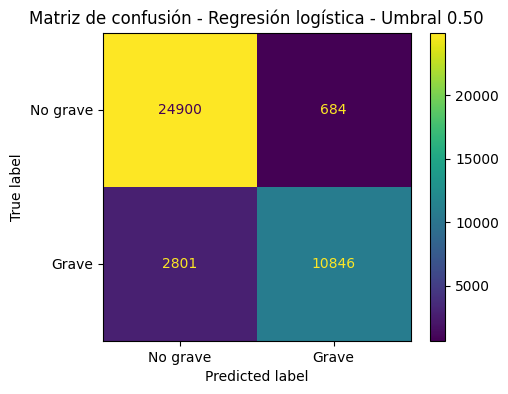

In [ ]:
# Se evalúa la regresión logística con umbral estándar de 0.50
metricas_logistica_050, matriz_logistica_050, y_pred_logistica_050, y_proba_logistica = evaluar_modelo_binario(
    nombre_modelo="Regresion_Logistica_umbral_0_50",
    modelo=mejor_modelo_logistica,
    X_eval=X_test,
    y_eval=y_test,
    umbral=0.50
)

print("Métricas de regresión logística con umbral 0.50:")
for clave, valor in metricas_logistica_050.items():
    print(f"{clave}: {valor}")

print("\nMatriz de confusión con umbral 0.50:")
print(matriz_logistica_050)

print("\nReporte de clasificación con umbral 0.50:")
print(
    classification_report(
        y_test,
        y_pred_logistica_050,
        target_names=["No grave", "Grave"],
        zero_division=0
    )
)

# Se genera la matriz de confusión con umbral estándar
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=matriz_logistica_050,
    display_labels=["No grave", "Grave"]
).plot(values_format="d", ax=ax)
plt.title("Matriz de confusión - Regresión logística - Umbral 0.50")
plt.show()

In [ ]:
# Se evalúan diferentes umbrales para la clase grave
umbrales_logistica = np.arange(0.20, 0.81, 0.05)
resultados_umbrales_logistica = []

for umbral in umbrales_logistica:
    y_pred_umbral_logistica = (y_proba_logistica >= umbral).astype(int)

    resultados_umbrales_logistica.append(
        {
            "umbral": umbral,
            "accuracy": accuracy_score(y_test, y_pred_umbral_logistica),
            "precision_grave": precision_score(y_test, y_pred_umbral_logistica, pos_label=1, zero_division=0),
            "recall_grave": recall_score(y_test, y_pred_umbral_logistica, pos_label=1, zero_division=0),
            "f1_grave": f1_score(y_test, y_pred_umbral_logistica, pos_label=1, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba_logistica),
            "pr_auc": average_precision_score(y_test, y_proba_logistica)
        }
    )

# Se construye la tabla de sensibilidad al umbral
df_umbrales_logistica = pd.DataFrame(resultados_umbrales_logistica)
df_umbrales_logistica.sort_values(by="f1_grave", ascending=False)

,umbral,accuracy,precision_grave,recall_grave,f1_grave,roc_auc,pr_auc
5,0.45,0.911422,0.929561,0.806478,0.863656,0.954044,0.941682
4,0.40,0.909561,0.912507,0.818495,0.862948,0.954044,0.941682
3,0.35,0.907395,0.890805,0.836301,0.862693,0.954044,0.941682
6,0.50,0.911167,0.940676,0.794753,0.861580,0.954044,0.941682
7,0.55,0.910020,0.948727,0.783689,0.858347,0.954044,0.941682
2,0.30,0.901736,0.861328,0.855206,0.858256,0.954044,0.941682
8,0.60,0.908950,0.955347,0.774456,0.855443,0.954044,0.941682
9,0.65,0.907395,0.961305,0.764564,0.851720,0.954044,0.941682
1,0.25,0.891489,0.823481,0.875797,0.848833,0.954044,0.941682
10,0.70,0.905712,0.965469,0.755990,0.847984,0.954044,0.941682


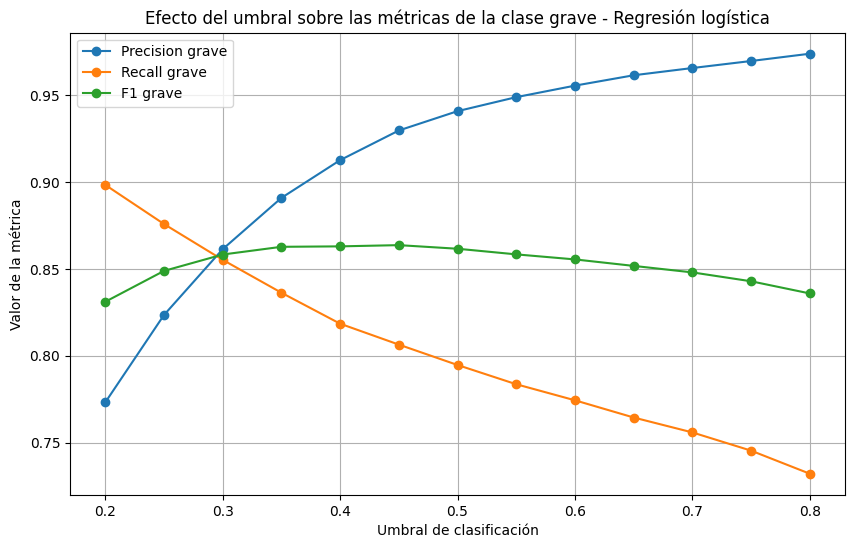

In [ ]:
# Se visualiza el efecto del umbral sobre precisión, recall y F1-score
plt.figure(figsize=(10, 6))
plt.plot(df_umbrales_logistica["umbral"], df_umbrales_logistica["precision_grave"], marker="o", label="Precision grave")
plt.plot(df_umbrales_logistica["umbral"], df_umbrales_logistica["recall_grave"], marker="o", label="Recall grave")
plt.plot(df_umbrales_logistica["umbral"], df_umbrales_logistica["f1_grave"], marker="o", label="F1 grave")

plt.xlabel("Umbral de clasificación")
plt.ylabel("Valor de la métrica")
plt.title("Efecto del umbral sobre las métricas de la clase grave - Regresión logística")
plt.legend()
plt.grid(True)
plt.show()

Mejor umbral de regresión logística según F1 grave: 0.44999999999999996


,umbral,accuracy,precision_grave,recall_grave,f1_grave,roc_auc,pr_auc
5,0.45,0.911422,0.929561,0.806478,0.863656,0.954044,0.941682



Métricas de regresión logística con umbral optimizado:
modelo: Regresion_Logistica_umbral_optimizado
umbral: 0.44999999999999996
accuracy: 0.9114220896739823
precision_grave: 0.9295608108108108
recall_grave: 0.8064776141276471
f1_grave: 0.8636559814807548
roc_auc: 0.9540443111450407
pr_auc: 0.941682399591482

Matriz de confusión con umbral optimizado:
[[24750   834]
 [ 2641 11006]]

Reporte de clasificación con umbral optimizado:
              precision    recall  f1-score   support

    No grave       0.90      0.97      0.93     25584
       Grave       0.93      0.81      0.86     13647

    accuracy                           0.91     39231
   macro avg       0.92      0.89      0.90     39231
weighted avg       0.91      0.91      0.91     39231



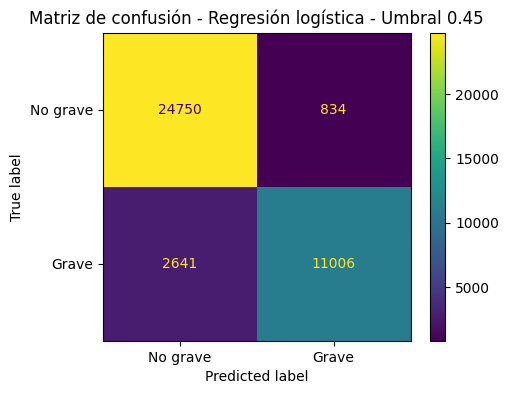

In [ ]:
# Se selecciona el mejor umbral para regresión logística según F1 de la clase grave
idx_mejor_umbral_logistica = df_umbrales_logistica["f1_grave"].idxmax()
mejor_umbral_logistica = df_umbrales_logistica.loc[idx_mejor_umbral_logistica, "umbral"]

# Se evalúa la regresión logística con el umbral optimizado
metricas_logistica_umbral, matriz_logistica_umbral, y_pred_logistica_umbral, y_proba_logistica_umbral = evaluar_modelo_binario(
    nombre_modelo="Regresion_Logistica_umbral_optimizado",
    modelo=mejor_modelo_logistica,
    X_eval=X_test,
    y_eval=y_test,
    umbral=mejor_umbral_logistica
)

print("Mejor umbral de regresión logística según F1 grave:", mejor_umbral_logistica)
display(df_umbrales_logistica.loc[[idx_mejor_umbral_logistica]])

print("\nMétricas de regresión logística con umbral optimizado:")
for clave, valor in metricas_logistica_umbral.items():
    print(f"{clave}: {valor}")

print("\nMatriz de confusión con umbral optimizado:")
print(matriz_logistica_umbral)

print("\nReporte de clasificación con umbral optimizado:")
print(
    classification_report(
        y_test,
        y_pred_logistica_umbral,
        target_names=["No grave", "Grave"],
        zero_division=0
    )
)

# Se genera la matriz de confusión con umbral optimizado
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=matriz_logistica_umbral,
    display_labels=["No grave", "Grave"]
).plot(values_format="d", ax=ax)
plt.title(f"Matriz de confusión - Regresión logística - Umbral {mejor_umbral_logistica:.2f}")
plt.show()

In [ ]:
# Se construye la tabla final de resultados de regresión logística
df_resultados_logistica = pd.DataFrame(
    [
        metricas_logistica_050,
        metricas_logistica_umbral
    ]
).sort_values(
    by="f1_grave",
    ascending=False
).reset_index(drop=True)

# Se presenta la comparación entre umbral estándar y umbral optimizado
display(df_resultados_logistica)

print("Mejor configuración de regresión logística según F1 grave:")
display(df_resultados_logistica.iloc[[0]])

,modelo,umbral,accuracy,precision_grave,recall_grave,f1_grave,roc_auc,pr_auc
0,Regresion_Logistica_umbral_optimizado,0.45,0.911422,0.929561,0.806478,0.863656,0.954044,0.941682
1,Regresion_Logistica_umbral_0_50,0.50,0.911167,0.940676,0.794753,0.861580,0.954044,0.941682


Mejor configuración de regresión logística según F1 grave:


,modelo,umbral,accuracy,precision_grave,recall_grave,f1_grave,roc_auc,pr_auc
0,Regresion_Logistica_umbral_optimizado,0.45,0.911422,0.929561,0.806478,0.863656,0.954044,0.941682


### **Conclusión del modelo logístico**

La regresión logística se utiliza como línea base interpretable para contrastar modelos más complejos como MLP y XGBoost. El uso de imputación, escalamiento y búsqueda de hiperparámetros permite obtener una versión estable del modelo y evaluar su desempeño bajo el mismo esquema de entrenamiento y prueba.

La selección final dentro de este notebook se realiza usando el F1-score de la clase grave, ya que esta métrica equilibra precisión y recall para la clase de mayor interés en el contexto de seguridad vial.